In [1]:
#rewrite code to index dictionary by spikeID keys

In [2]:
#imports
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append(r'..\..\..\spikeparam')

from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import os

from fooof import FOOOF

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

#import IProgress

import openpyxl
import glob

import pickle

C:\Users\david\AppData\Local\Temp\ipykernel_16856\1582795719.py:45: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


### Defining useful functions

In [3]:
# Function to visualize sweep patch data
# no metadata, just the time series data
def extract_data(file_path, plot_data = False):
    """
    Extracts data from an HDF5 file and optionally plots the data.

    This function opens an HDF5 file, extracts data from each sweep in the 'acquisition' group, 
    and stores the data in a list of NumPy arrays. If the plot_data flag is set to True, the 
    function also plots the data. It handles both 1D and 2D data, but prints a message if the 
    data has more than 2 dimensions.

    Parameters:
    - file_path (str): The path to the HDF5 file.
    - plot_data (bool): A flag indicating whether to plot the extracted data. Default is False.

    Returns:
    - list: A list of NumPy arrays containing the extracted data for each sweep.
    """
    # Open the HDF5 file
    with h5py.File(file_path, 'r') as f:
        # Initialize an empty list to store data arrays
        data = []

        # Iterate through keys in the 'acquisition' group
        for sweep_key in f['acquisition'].keys():
            dataset = f['acquisition'][sweep_key]['data'] 
            # Convert the dataset data into a NumPy array and append to the list
            data.append(np.array(dataset))

        # Plot the data
        if(plot_data):
            if all(d.ndim == 1 for d in data):
                for d in data:
                    plt.plot(d)
                plt.xlabel('time (ms)')
                plt.ylabel('mV')
                plt.title('1D Dataset Visualization')
                plt.show()
            elif all(d.ndim == 2 for d in data):
                for d in data:
                    plt.imshow(d, cmap='viridis')
                    plt.colorbar()
                    plt.xlabel('X-axis')
                    plt.ylabel('Y-axis')
                    plt.title('2D Dataset Visualization')
                    plt.show()
            else:
                print("Cannot visualize data with more than 2 dimensions.")



        return data

In [4]:
#collecting file paths

def get_file_paths(folder_path):
    """
    Function to loop through a folder and save file paths.
    
    Args:
    - folder_path (str): Path to the folder to loop through.
    
    Returns:
    - file_paths (list): List of file paths found in the folder.
    """
    file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths 


In [5]:
# Functions to save a datrame to a pickle file and another to extract the data from the pickle file

def save_dataframe_to_pickle(dataframe, file_path):
    """
    Function to save a DataFrame as a pickle file.
    
    Args:
    - dataframe (pd.DataFrame): DataFrame to be saved.
    - file_path (str): Path to save the pickle file.
    """
    dataframe.to_pickle(file_path)

def load_dataframe_from_pickle(file_path):
    """
    Function to extract a DataFrame from a pickle file.
    
    Args:
    - file_path (str): Path to the pickle file.
    
    Returns:
    - dataframe (pd.DataFrame): Loaded DataFrame.
    """
    dataframe = pd.read_pickle(file_path)
    return dataframe

def save_dict_to_pickle(dictionary, filepath):
    """
    Save a dictionary to a pickle file.

    Parameters:
        dictionary (dict): The dictionary to save.
        filepath (str): The path to the pickle file.
    """
    with open(filepath, 'wb') as f:
        pickle.dump(dictionary, f)
    print(f"Dictionary saved to {filepath}")


def load_dict_from_pickle(filepath):
    """
    Load a dictionary from a pickle file.

    Parameters:
        filepath (str): The path to the pickle file.

    Returns:
        dict: The loaded dictionary.
    """
    with open(filepath, 'rb') as f:
        dictionary = pickle.load(f)
    print(f"Dictionary loaded from {filepath}")
    return dictionary

In [40]:
def compute_firing_rates(dir_list, allMonkey_df):
    """
    Computes firing rates per sweep from the given directory of files.

    Parameters:
    - dir_list (str): list of Paths to the directories  of files.
    - allMonkey_df (pd.DataFrame): DataFrame containing spike information, including the 'spikeID' column.

    Returns:
    - dict: A dictionary where keys are sweep identifiers and values are firing rates.
    """
    firing_rates = {}

    # Loop through all subdirectories and files
    for files in dir_list:
        file_num = 0
        file_list = [os.path.join(files, f) for f in os.listdir(files) if os.path.isfile(os.path.join(files, f))]
        for file in file_list:
            if file.endswith(".nwb"):  # Adjust if files have a different extension
                #file_path = os.path.join(root, file)

                with h5py.File(file, 'r') as f:
                    monkey_id = os.path.basename(os.path.dirname(file))  # Extract Monkey_ID
                    file_name = os.path.splitext(os.path.basename(file))[0]
                    

                    for sweep_key in f['acquisition'].keys():
                        dataset = f['acquisition'][sweep_key]['data']
                        sweep_length = len(np.array(dataset))  # Convert dataset to NumPy array and find length

                        # Create unique key for sweep
                        sweep_key_str = f"{monkey_id}f{file_num}Sw{sweep_key}"
            
                        # Count matching spike occurrences in allMonkey_df
                        spike_count = allMonkey_df['Spike_ID'].str.contains(sweep_key_str, na=False).sum()
                        if spike_count == 0:
                            continue
                        # Compute firing rate: spikes per second
                        firing_rate = spike_count / (sweep_length / 10000)  # Assuming 10 kHz sampling rate

                        firing_rates[sweep_key_str] = firing_rate
                        

            file_num+=1

    return firing_rates


### Firing rate

In [37]:

allMonkey_df = load_dataframe_from_pickle(r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\allMonkey_df.pkl")
allMonkey_df.head()

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,...,Spike_#,Spike_ID,file_name,dendriticType,SomaLayerLoc,brainOrigin,Weight,Sex,Age,Species
0,2.612488,0.45,-45.858766,15.164185,0.50,6.445313,6.970228,-56.733916,88.40,0.996142,...,0,M03f0SwSweep_10Sp0,M03_JS_A1_C01,A,3.0,PFC,6.3,F,9.96,Macaca fascicularis
1,1.832248,0.60,-38.827516,11.984253,0.55,3.929138,5.981717,-53.646425,56.35,0.950116,...,1,M03f0SwSweep_10Sp1,M03_JS_A1_C01,A,3.0,PFC,6.3,F,9.96,Macaca fascicularis
2,1.725643,0.60,-38.571168,11.453247,0.55,3.533936,6.194347,-53.275150,56.20,0.969743,...,2,M03f0SwSweep_10Sp2,M03_JS_A1_C01,A,3.0,PFC,6.3,F,9.96,Macaca fascicularis
3,1.762723,0.60,-39.727784,11.669922,0.60,3.567505,5.819483,-53.277108,NaN,0.975530,...,3,M03f0SwSweep_10Sp3,M03_JS_A1_C01,A,3.0,PFC,6.3,F,9.96,Macaca fascicularis
4,2.534657,0.50,-46.746827,15.621949,0.50,6.254578,7.821646,-56.351455,90.70,0.982983,...,0,M03f0SwSweep_11Sp0,M03_JS_A1_C01,A,3.0,PFC,6.3,F,9.96,Macaca fascicularis


In [41]:
file_list = [r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M03", r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M04", r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M05"
             ,r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M06", r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M08"
             , r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M10", r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M11"
             , r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M12", r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M19"
             , r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M20", r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\M21"]
firing_rates = compute_firing_rates(file_list, allMonkey_df)
save_dict_to_pickle(firing_rates, r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\firing_rates.pkl")

Dictionary saved to C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\firing_rates.pkl


In [42]:
display(firing_rates)

{'M03f0SwSweep_1': np.float64(3.05),
 'M03f0SwSweep_10': np.float64(0.2),
 'M03f0SwSweep_11': np.float64(0.7),
 'M03f0SwSweep_12': np.float64(0.6),
 'M03f0SwSweep_13': np.float64(0.8),
 'M03f0SwSweep_14': np.float64(0.75),
 'M03f0SwSweep_5': np.float64(0.05),
 'M03f0SwSweep_54': np.float64(5.0),
 'M03f0SwSweep_7': np.float64(0.1),
 'M03f0SwSweep_8': np.float64(0.05),
 'M03f0SwSweep_9': np.float64(0.15),
 'M03f1SwSweep_1': np.float64(3.6),
 'M03f1SwSweep_10': np.float64(0.5),
 'M03f1SwSweep_11': np.float64(0.75),
 'M03f1SwSweep_12': np.float64(0.75),
 'M03f1SwSweep_13': np.float64(0.8),
 'M03f1SwSweep_14': np.float64(0.8),
 'M03f1SwSweep_3': np.float64(0.1),
 'M03f1SwSweep_38': np.float64(5.0),
 'M03f1SwSweep_39': np.float64(5.0),
 'M03f1SwSweep_4': np.float64(0.05),
 'M03f1SwSweep_40': np.float64(5.0),
 'M03f2SwSweep_1': np.float64(3.85),
 'M03f2SwSweep_10': np.float64(0.85),
 'M03f2SwSweep_101': np.float64(5.0),
 'M03f2SwSweep_102': np.float64(5.0),
 'M03f2SwSweep_103': np.float64(5.0

### Filtering

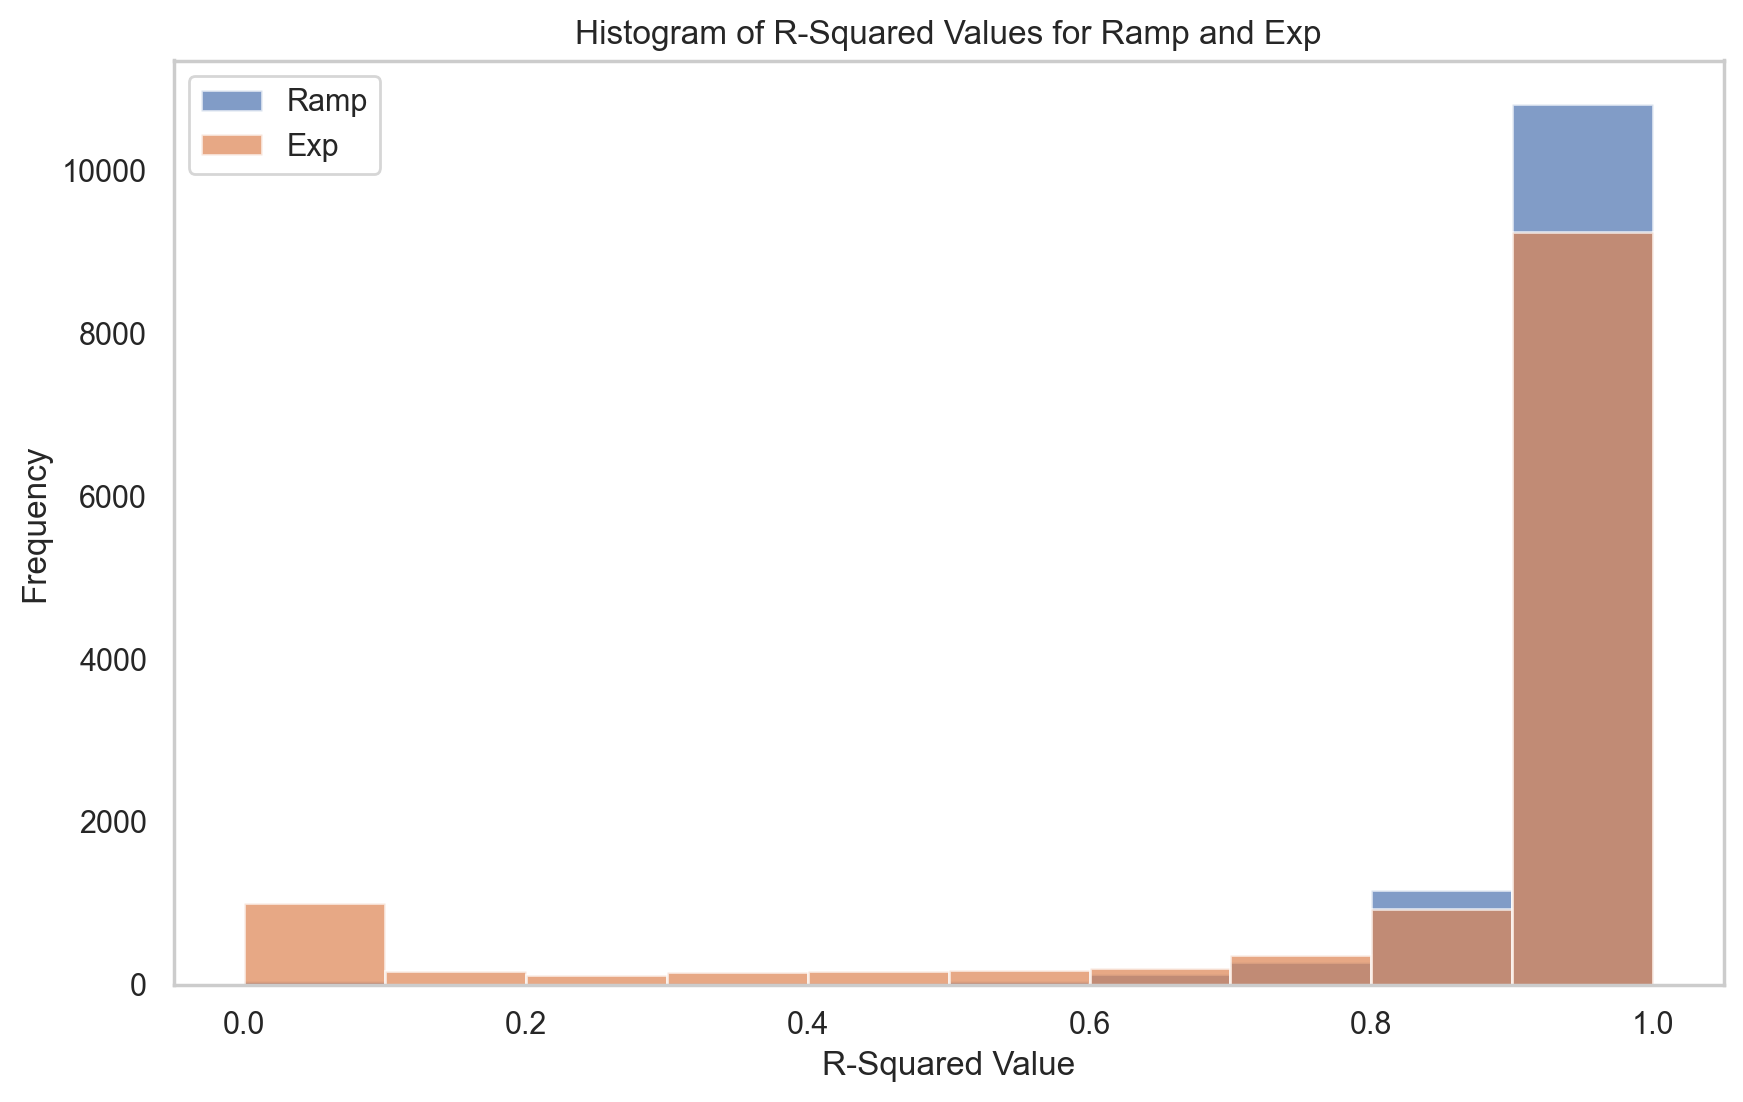

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(allMonkey_df['r_squared_ramp'], bins=10, alpha=0.7, label='Ramp')
plt.hist(allMonkey_df['r_squared_exp'], bins=10, alpha=0.7, label='Exp')

plt.title('Histogram of R-Squared Values for Ramp and Exp')
plt.xlabel('R-Squared Value')
plt.ylabel('Frequency')

plt.legend()

plt.show()

In [10]:
combined_dict = load_dict_from_pickle(r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\combined_dict.pkl")

Dictionary loaded from C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\combined_dict.pkl


In [11]:
len(combined_dict.keys())

12550

In [12]:
allMonkey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12550 entries, 0 to 12549
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ramp_amp         12546 non-null  float64
 1   inflection_time  12546 non-null  float64
 2   inflection_amp   12546 non-null  float64
 3   peak_amp         12546 non-null  float64
 4   peak_width       12546 non-null  float64
 5   peak_sharpness   12546 non-null  float64
 6   exp_lambda       12546 non-null  float64
 7   exp_const        12546 non-null  float64
 8   isi              9848 non-null   float64
 9   r_squared_ramp   12518 non-null  float64
 10  r_squared_exp    12508 non-null  float64
 11  Sweep_#          12550 non-null  object 
 12  Spike_#          12550 non-null  int64  
 13  Spike_ID         12550 non-null  object 
 14  file_name        12550 non-null  object 
 15  dendriticType    7549 non-null   object 
 16  SomaLayerLoc     7958 non-null   object 
 17  brainOrigin 

In [13]:
error_keys = []
for i in allMonkey_df['Spike_ID']:
    try:
        value = combined_dict[i]  # Attempt to access the key
    except KeyError:
        error_keys.append(i) 
print(error_keys)

[]


In [14]:
error_keys = []
for i in combined_dict.keys():
    try:
        value = allMonkey_df.loc[i, 'Spike_ID']
    except KeyError:
        error_keys.append(i) 
print(len(error_keys))

12550


In [15]:
# Convert 'Spike_ID' column values to a set for fast lookup
spike_id_set = set(allMonkey_df['Spike_ID'])

# Find keys in the dictionary that are not in the DataFrame
missing_keys = set(combined_dict.keys()) - spike_id_set

# Print results
if missing_keys:
    print(f"Keys in all_Monkey_dict but not in allMonkey_df['Spike_ID']: {len(missing_keys)} missing")
    print(missing_keys)  # Print missing keys (optional)
else:
    print("All keys in all_Monkey_dict are present in allMonkey_df['Spike_ID']")


All keys in all_Monkey_dict are present in allMonkey_df['Spike_ID']


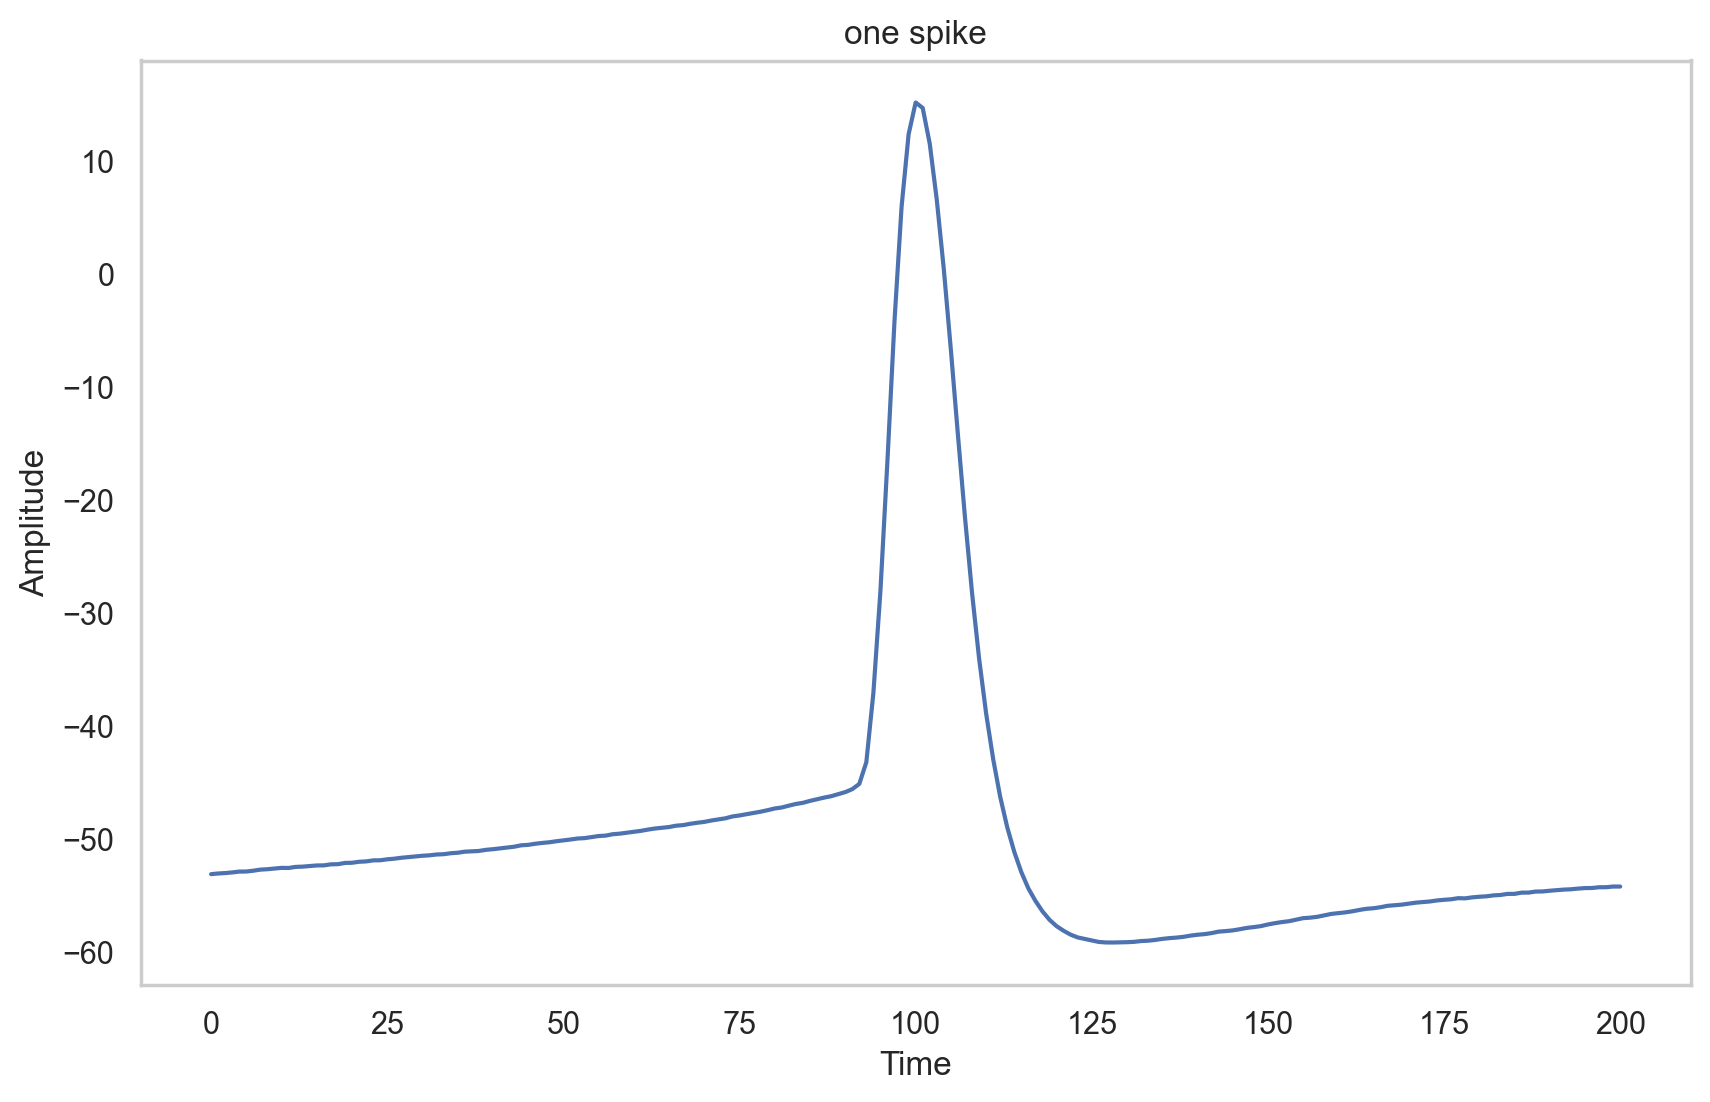

In [16]:
plt.figure(figsize=(10, 6))
spikes = combined_dict['M03f0SwSweep_10Sp0']
plt.plot(spikes)
plt.title('one spike')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

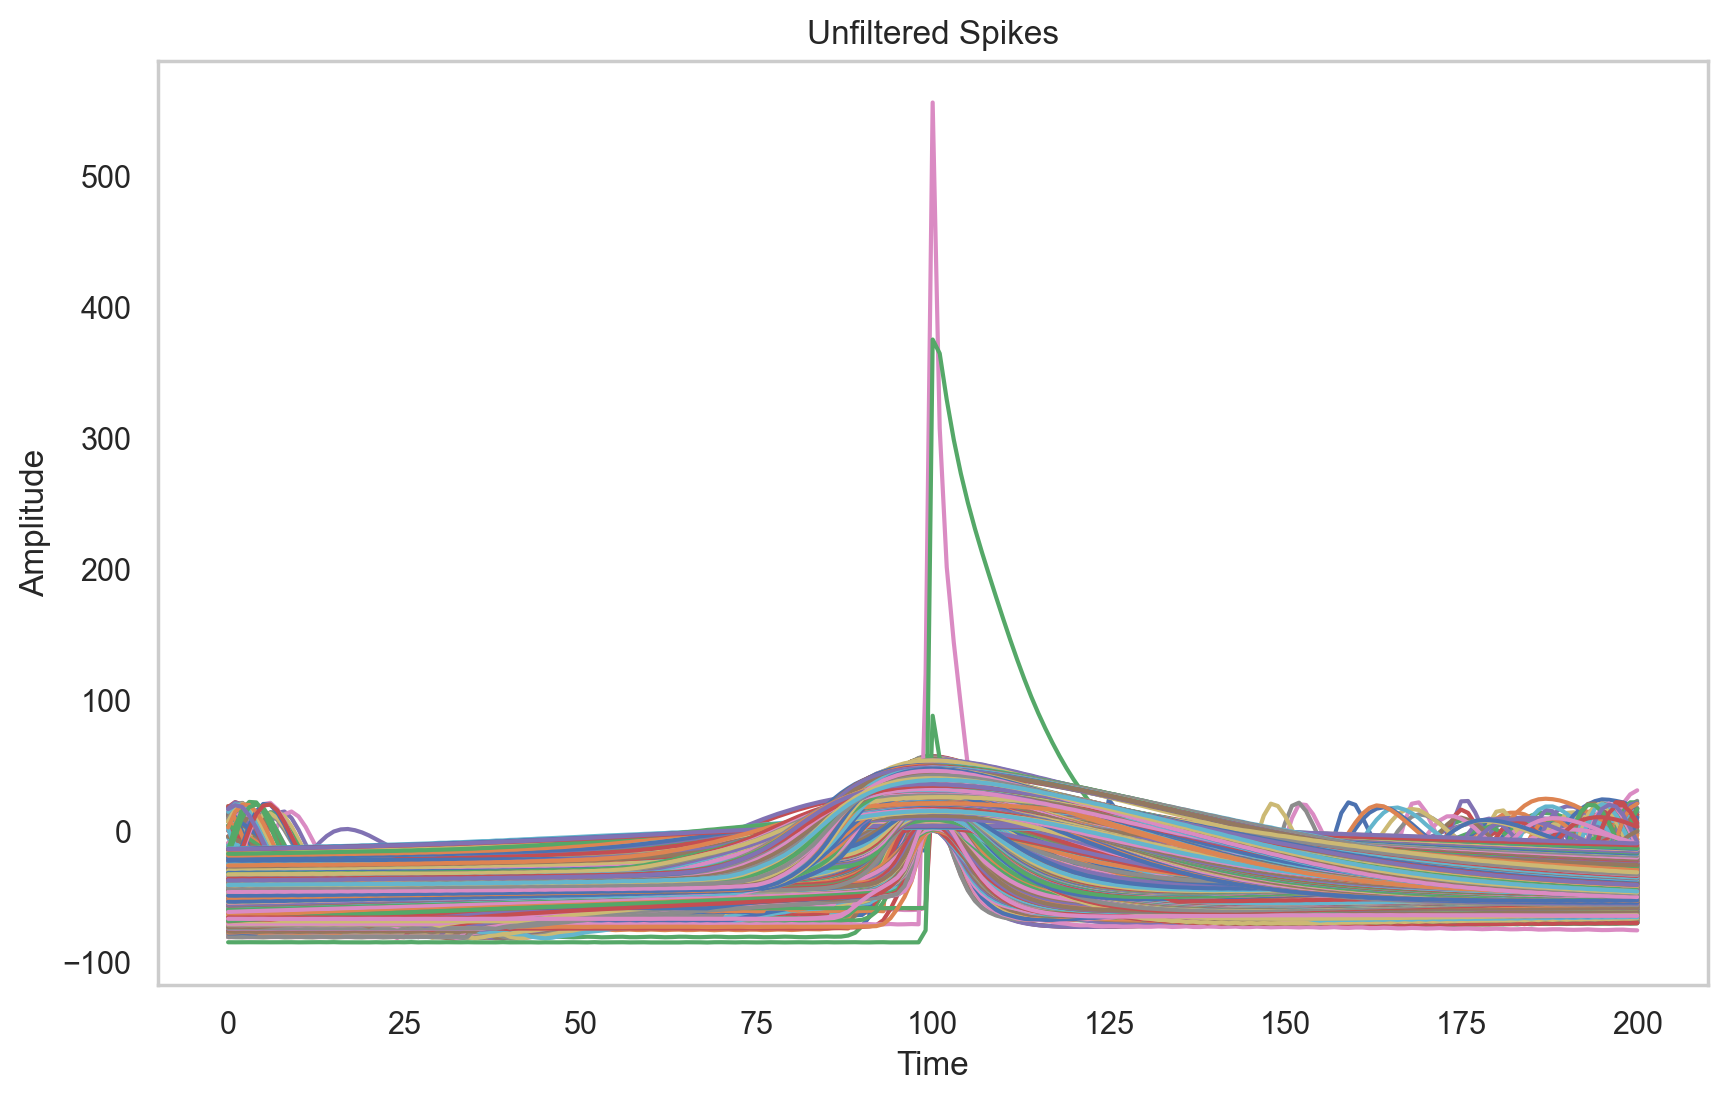

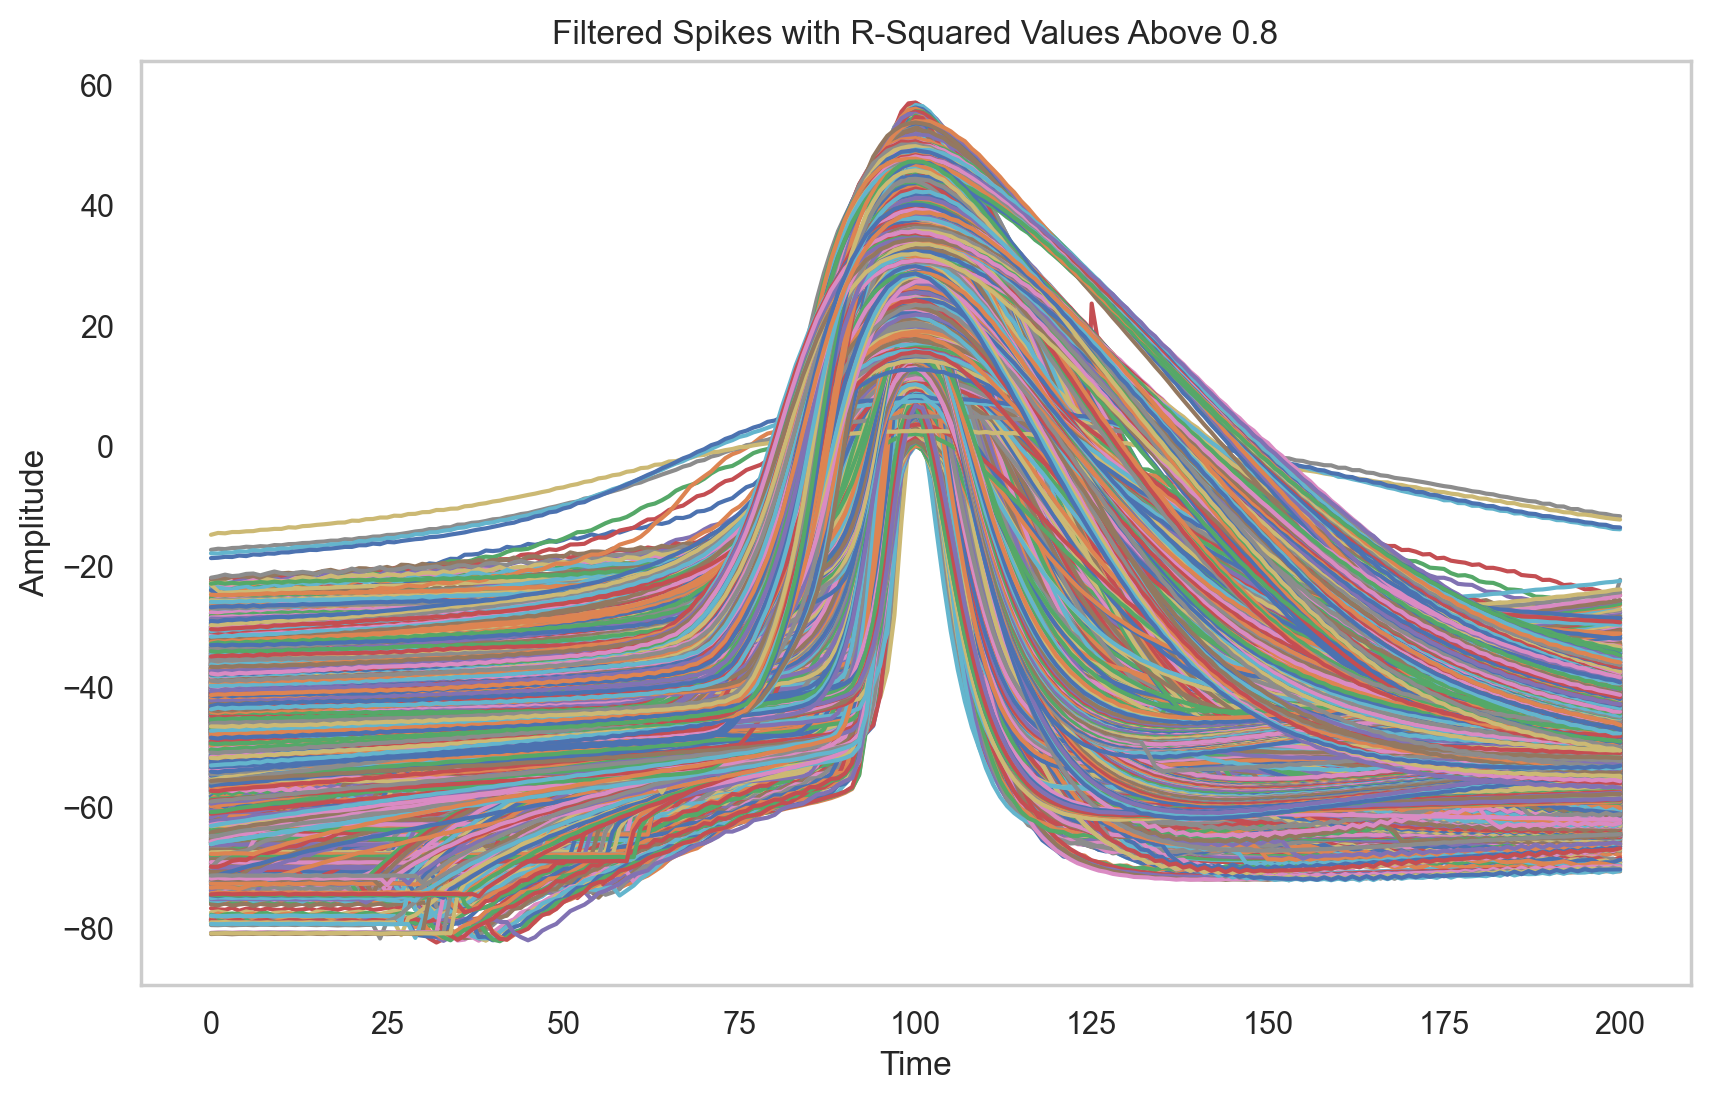

In [17]:
plt.figure(figsize=(10, 6))
for key, spikes in combined_dict.items():
    plt.plot(spikes)
plt.title('Unfiltered Spikes')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

allMonkey_df_filt = allMonkey_df[(allMonkey_df['r_squared_ramp'] >= 0.8) & (allMonkey_df['r_squared_exp'] >= 0.8) & (allMonkey_df['inflection_time'] >= 0) & (allMonkey_df['inflection_time'] <= 2)].copy()
#allMonkey_df_filt = allMonkey_df[(allMonkey_df['inflection_time'] >= 0) & (allMonkey_df['inflection_time'] <= 2)].copy()
combined_dict_filt = {}

allMonkey_df_filt['log_isi'] = np.log10(allMonkey_df['isi'])
allMonkey_df_filt.drop('isi', axis=1, inplace=True)
used_keys = set()

for index, row in allMonkey_df_filt.iterrows():
    key = row['Spike_ID']

    if key in combined_dict and key not in used_keys:
        combined_dict_filt[key] = combined_dict[key]
        used_keys.add(key)

plt.figure(figsize=(10, 6))
for key, spikes in combined_dict_filt.items():
    plt.plot(spikes)

plt.title('Filtered Spikes with R-Squared Values Above 0.8')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()



In [18]:
allMonkey_df_filt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9302 entries, 1 to 12549
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ramp_amp         9302 non-null   float64
 1   inflection_time  9302 non-null   float64
 2   inflection_amp   9302 non-null   float64
 3   peak_amp         9302 non-null   float64
 4   peak_width       9302 non-null   float64
 5   peak_sharpness   9302 non-null   float64
 6   exp_lambda       9302 non-null   float64
 7   exp_const        9302 non-null   float64
 8   r_squared_ramp   9302 non-null   float64
 9   r_squared_exp    9302 non-null   float64
 10  Sweep_#          9302 non-null   object 
 11  Spike_#          9302 non-null   int64  
 12  Spike_ID         9302 non-null   object 
 13  file_name        9302 non-null   object 
 14  dendriticType    5698 non-null   object 
 15  SomaLayerLoc     6030 non-null   object 
 16  brainOrigin      9302 non-null   object 
 17  Weight           9

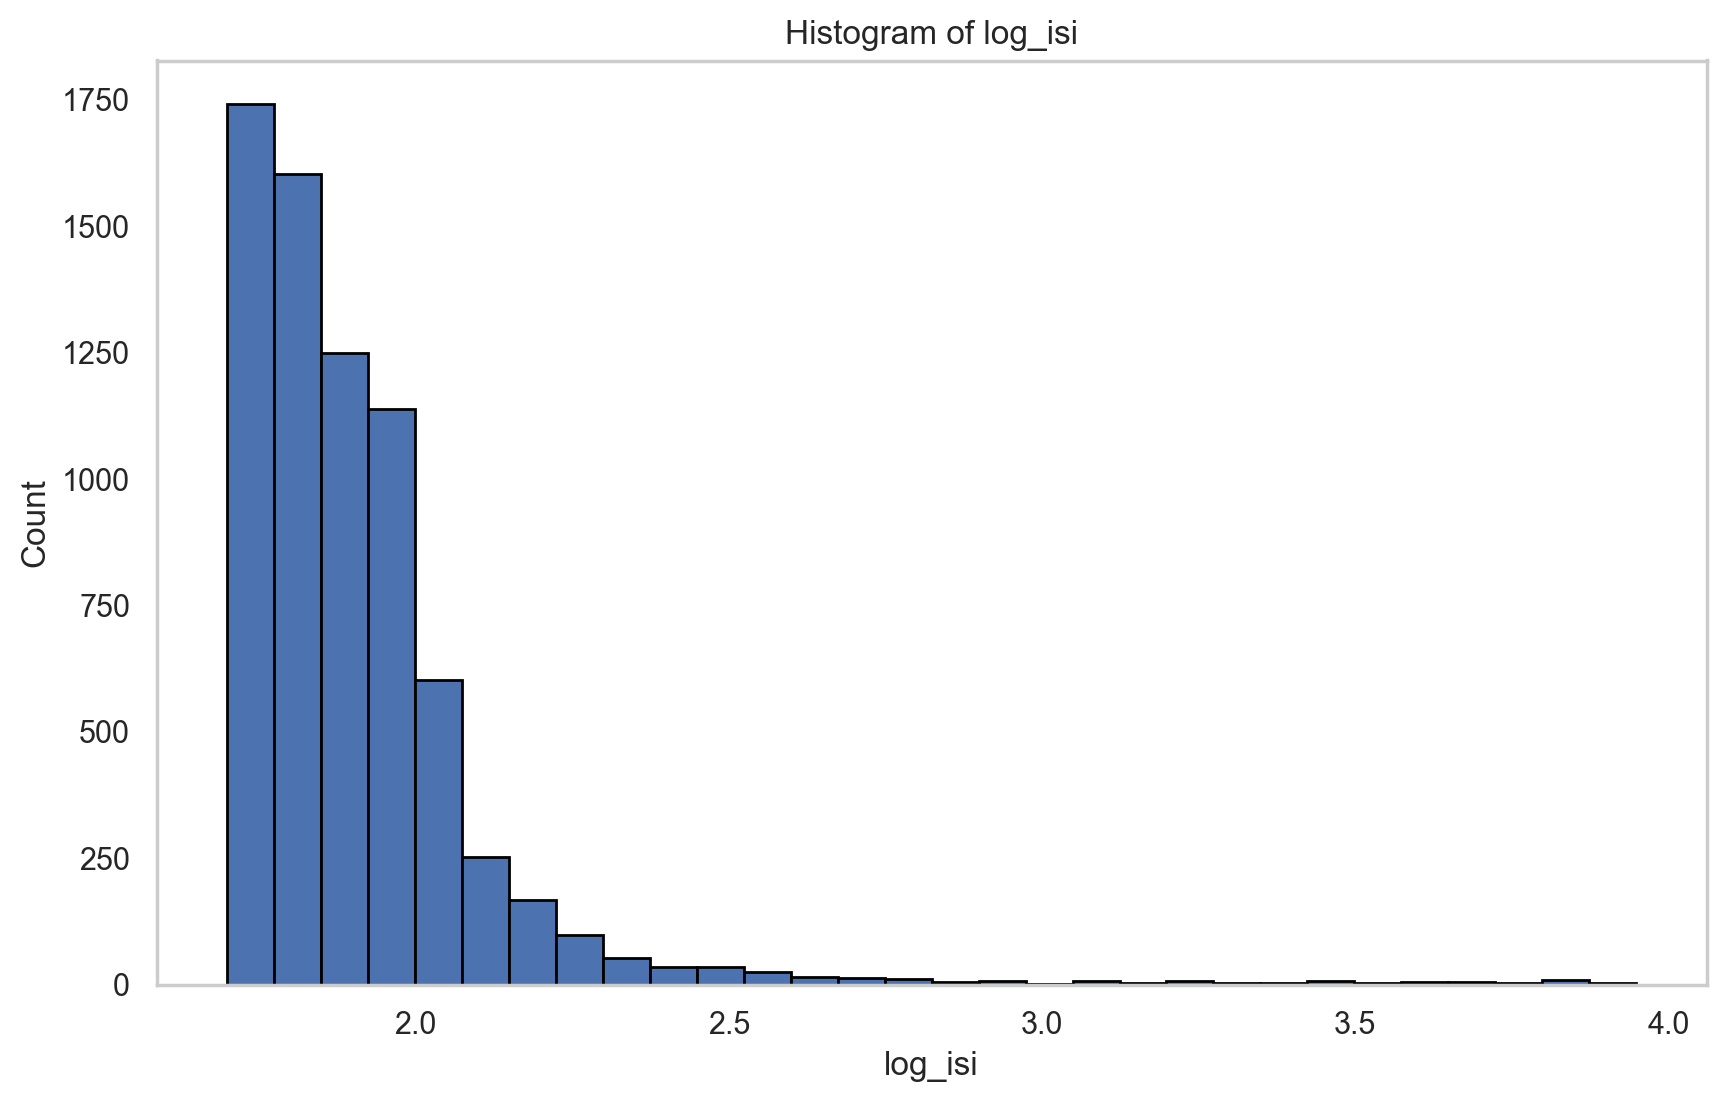

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(allMonkey_df_filt['log_isi'], bins=30, edgecolor='black')

# Formatting
plt.xlabel('log_isi')
plt.ylabel('Count')
plt.title('Histogram of log_isi')
plt.show()


In [20]:
# Columns to replace NaN with “unknown”
columns_to_replace = ["dendriticType", "SomaLayerLoc"]
# Replace NaN in the selected columns
allMonkey_df_filt[columns_to_replace] = allMonkey_df_filt[columns_to_replace].fillna("unknown")

In [21]:
#allMonkey_df_filt = allMonkey_df_filt.dropna()
save_dataframe_to_pickle(allMonkey_df_filt, r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\allMonkey_df_filt.pkl")
save_dict_to_pickle(combined_dict_filt, r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\combined_dict_filt.pkl")

Dictionary saved to C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\combined_dict_filt.pkl


### ANOVAS and Posthoc tests

In [22]:

allMonkey_df_filt = load_dataframe_from_pickle(r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\allMonkey_df_filt.pkl")
allMonkey_df_filt.tail()


,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,r_squared_ramp,r_squared_exp,...,Spike_ID,file_name,dendriticType,SomaLayerLoc,brainOrigin,Weight,Sex,Age,Species,log_isi
12545,1.914118,1.35,-42.074463,44.442871,2.50,0.457764,0.338319,-81.006579,0.958351,0.994337,...,M21f12SwSweep_8Sp0,M21_SA_A1_C07,S,3.0,V1,8.7,M,7.65,Macaca fascicularis,NaN
12546,1.846199,1.35,-42.471191,45.846680,2.45,0.442505,0.359868,-78.247398,0.923707,0.995102,...,M21f12SwSweep_9Sp0,M21_SA_A1_C07,S,3.0,V1,8.7,M,7.65,Macaca fascicularis,2.085291
12547,2.099518,1.45,-39.785645,42.367676,2.55,0.381470,0.299768,-84.266822,0.944645,0.994975,...,M21f12SwSweep_9Sp1,M21_SA_A1_C07,S,3.0,V1,8.7,M,7.65,Macaca fascicularis,2.406540
12548,2.276198,1.55,-37.100098,40.139893,2.65,0.335693,0.304954,-81.487302,0.930923,0.994197,...,M21f12SwSweep_9Sp2,M21_SA_A1_C07,S,3.0,V1,8.7,M,7.65,Macaca fascicularis,2.555759
12549,2.398728,1.60,-36.886475,38.888672,2.75,0.350952,0.279030,-85.988248,0.954351,0.993531,...,M21f12SwSweep_9Sp3,M21_SA_A1_C07,S,3.0,V1,8.7,M,7.65,Macaca fascicularis,NaN


In [23]:

'''
Run this one first, check for significance before running posthoc

significant if p-value < 0.005
'''


# Assuming you have a dataframe `df`
# Load your dataframe here
df = allMonkey_df_filt
# Define the spike features and conditions
spike_features = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                       'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']
conditions = ['dendriticType',	'SomaLayerLoc','brainOrigin',	'Weight',	'Sex',	'Age',	'Species']
# Initialize a dictionary to store ANOVA results
anova_results = {feature: {} for feature in spike_features}
# Perform ANOVA for each spike feature against each condition
for feature in spike_features:
    for condition in conditions:
        groups = [df[feature][df[condition] == cond] for cond in df[condition].unique()]
        anova_results[feature][condition] = scipy.stats.f_oneway(*groups)
# Print the ANOVA results
for feature, results in anova_results.items():
    print(f"ANOVA results for {feature}:")
    for condition, result in results.items():
        if result:
            f_value, p_value = result
            print(f"  Condition: {condition}, F-value: {f_value}, p-value: {p_value:.10e}")


KeyError: 'isi'

In [ ]:
# Assuming df is defined and the relevant libraries are imported
df = allMonkey_df_filt

# Define the spike features and conditions
spike_features = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                  'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']
conditions = ['dendriticType', 'SomaLayerLoc', 'brainOrigin', 'Weight', 'Sex', 'Age', 'Species']

# Initialize a dictionary to store ANOVA results
anova_results = {feature: {} for feature in spike_features}

# Perform ANOVA for each spike feature against each condition
for feature in spike_features:
    for condition in conditions:
        groups = [df[feature][df[condition] == cond] for cond in df[condition].unique()]
        print(groups)
        anova_results[feature][condition] = scipy.stats.f_oneway(*groups)

# Extract and print the ANOVA results for 'ramp_amp' under the condition 'brainOrigin'
feature = 'ramp_amp'
condition = 'brainOrigin'
result = anova_results[feature][condition]
print(f'ANOVA results for {feature} under the condition of {condition}:')
print(f'  F-value: {result.statistic}, p-value: {result.pvalue}')

In [ ]:


#put following into function then call in next notbook

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Define the dependent variables
dependent_vars = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                  'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']

# Define the condition
condition = 'brainOrigin'

# Initialize a dictionary to store ANOVA results
results = {}

# Perform ANOVA for each dependent variable against the specified condition
for dep_var in dependent_vars:
    model_formula = f'{dep_var} ~ C({condition})'
    model = smf.ols(model_formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    results[dep_var] = anova_table

# Print results for each dependent variable
for dep_var, result in results.items():
    print(f'ANOVA results for {dep_var}:\n{result}\n')


In [ ]:
#%pip install pingouin
import pingouin as pg

pg.anova(dv='peak_width', 
         between='brainOrigin', 
         data=allMonkey_df_filt,
         detailed=True)

In [ ]:
# perform Tukey's test
tukey = pairwise_tukeyhsd(endog=df['isi'],
                          groups=df['Sex'],
                          alpha=0.05)

print(tukey)

In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Assuming df is defined and contains the relevant data
df = allMonkey_df_filt

# Define the spike features and conditions
spike_features = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                  'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']
conditions = ['dendriticType', 'SomaLayerLoc', 'brainOrigin', 'Weight', 'Sex', 'Age', 'Species']

# Initialize a dictionary to store Tukey's test results
tukey_results = {feature: {} for feature in spike_features}

# Perform ANOVA and Tukey's test for each spike feature against each condition
for feature in spike_features:
    for condition in conditions:
        model_formula = f'{feature} ~ C({condition})'
        model = smf.ols(model_formula, data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        
        # If ANOVA shows significant results, perform Tukey's test
        if anova_table["PR(>F)"].iloc[0] < 0.05:
            try:
                tukey = pairwise_tukeyhsd(endog=df[feature].astype(float),
                                          groups=df[condition].astype(str),
                                          alpha=0.05)
                tukey_results[feature][condition] = tukey
            except Exception as e:
                print(f'Error performing Tukey\'s test for {feature} under {condition}: {e}')

# Print the Tukey's test results for each combination of feature and condition
for feature, results in tukey_results.items():
    print(f'Tukey\'s test results for {feature}:')
    for condition, result in results.items():
        print(f'\nCondition: {condition}')
        print(result)
        print('\n')


### Data plots

In [ ]:
combined_dict_filt = load_dict_from_pickle(r"C:\Users\david\Documents\Voytek Research\spike_proj\primate Dataset\combined_dict_filt.pkl")

In [ ]:
len(combined_dict_filt)

In [ ]:
def boxplots_by_Param(param):
    """
    Generates box plots for specific columns in a DataFrame, grouped by a specified parameter.

    This function creates box plots for a predefined list of columns, with the data grouped by the values of the specified parameter. 
    The box plots provide a visual summary of the distribution of the data for each group, highlighting the median, quartiles, and potential outliers.

    Parameters:
    - param (str): The column name in the DataFrame by which to group the data.
        Each unique value in this column will form a separate group in the box plots.

    Returns:
    None: The function displays the box plots.
    """
    # Set the style of the plots
    sns.set(style="whitegrid")
    
    # Define the list of columns to plot
    columns_to_plot = ['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp', 'peak_width', 
                       'peak_sharpness', 'exp_lambda', 'exp_const', 'isi', 'r_squared_ramp']
    
    # Create box plots for each column controlling for 'brainOrigin'
    for column in columns_to_plot:
        plt.figure(figsize=(10, 6))
        
        sns.boxplot(x=param, y=column, data=allMonkey_df_filt)
        plt.title(f'Box Plot of {column} by {param}')
        plt.xlabel(param)
        plt.ylabel(column)
        plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
        plt.show()

boxplots_by_Param('Age')

In [ ]:
boxplots_by_Param('Species')

In [ ]:
boxplots_by_Param('brainOrigin')

In [ ]:
boxplots_by_Param('SomaLayerLoc')

In [ ]:
boxplots_by_Param('Sex')

In [ ]:
boxplots_by_Param('dendriticType')

In [ ]:
def plot_waveform(df, combined_dict_filt, metadata_param = None, median = False, Overlapped = False):
    """
    Plots the average spike waveforms with standard deviation shading.

    This function generates plots of average spike waveforms from a dictionary of spike data. The function can filter
    the data based on a specified metadata parameter and plot the results either separately or overlapped.

    Parameters:
    - df (pd.DataFrame): The DataFrame containing metadata about the spike data.
    - combined_dict_filt (dict): A dictionary where keys are formatted as "{file_name} {Sweep_#}" and values are arrays of spike data.
    - metadata_param (str, optional): The column name in the DataFrame to filter the data by. Each unique value in this column will have its own plot.
    - median (bool, optional): If True, calculates the median spike waveform instead of the mean.
    - Overlapped (bool, optional): If True, plots the average waveforms for all unique values of the metadata parameter on a single plot.
        If False, creates separate plots for each unique value.

    Returns:
    None: The function displays the plots.
    """
    if metadata_param is not None:
        parameters = df[metadata_param].unique()

        if Overlapped: # Create the plot
            plt.figure(figsize=(10, 6))
             # Set the labels and title
            plt.xlabel('Time')
            plt.ylabel('mVs')
            plt.ylim(-80, 55)
            plt.title('Overall Average Spike with Standard Deviation for ' + str(metadata_param))
        for value in parameters:
            # Filter the DataFrame for the current unique value
            param_data = df[df[metadata_param] == value]
            all_spikes = []

            for index, row in param_data.iterrows():
                key = row['Spike_ID']
            
                if key in combined_dict_filt:
                    all_spikes.append(np.array(combined_dict_filt[key]))  # Preserve spike structure
            
            # Convert the list of spike arrays into a 2D NumPy array
            if len(all_spikes) > 0:
                all_spikes_array = np.array(all_spikes, dtype=object)  # Keeps each row variable-length (in case of varying  lengths)
                all_spikes_array = np.vstack(all_spikes)  # Stack into 2D array
            else:
                print(f"No valid spikes found for {metadata_param}")
                continue


            if not Overlapped:
                # Create the plot
                plt.figure(figsize=(10, 6))
                # Set the labels and title
                plt.xlabel('Time')
                plt.ylabel('mVs')
                plt.ylim(-75, 55)
                plt.title('Overall Average Spike with Standard Deviation for ' + str(value))
            # Calculate the average and standard deviation across all spike arrays
            if median:    
                mean_spike = np.median(all_spikes_array, axis=0)
            else:
                mean_spike = np.mean(all_spikes_array, axis=0)
            std_spike = np.std(all_spikes_array, axis=0)
                    
            plt.plot(mean_spike, label=f'Average Spike {metadata_param}:{value}')
            plt.fill_between(range(len(mean_spike)), mean_spike - std_spike, mean_spike + std_spike,
                             alpha=0.2, label='±1 Standard Deviation')
        
            if not Overlapped:    #plots individual graphs
                plt.legend()
                plt.show()

        if Overlapped:           #plots overlapped graphs
            plt.legend()
            plt.show()

    else:                       #creates an average spike graph of all spikes
        all_spikes = []

        # Aggregate all spike arrays from all keys
        for key, spike_data in combined_dict_filt.items():
            all_spikes.append(spike_data)
        
        # Convert the list of all spikes to a numpy array for easier manipulation
        all_spikes_array = np.array(all_spikes)
    
        # Calculate the average and standard deviation across all spike arrays
        mean_spike = np.mean(all_spikes_array, axis=0)
        std_spike = np.std(all_spikes_array, axis=0)
    
        # Create the plot
        plt.figure(figsize=(10, 6))
        plt.plot(mean_spike, label='Average Spike', color='b')
        plt.fill_between(range(len(mean_spike)), mean_spike - std_spike, mean_spike + std_spike, 
                         color='b', alpha=0.2, label='±1 Standard Deviation')
        
        # Set the labels and title
        plt.xlabel('Time')
        plt.ylabel('mVs')
        plt.title('Overall Average Spike with Standard Deviation')
        plt.legend()
    
        # Show the plot
        plt.show()


In [ ]:
plot_waveform(allMonkey_df_filt, combined_dict_filt, "brainOrigin", Overlapped=True)

In [ ]:
plot_waveform(allMonkey_df_filt, combined_dict_filt, 'Species', Overlapped=True)

In [ ]:
plot_waveform(allMonkey_df_filt, combined_dict_filt, 'Age', True, True)

In [ ]:
plot_waveform(allMonkey_df_filt, combined_dict_filt,'SomaLayerLoc', Overlapped=True)

In [ ]:
plot_waveform(allMonkey_df_filt, combined_dict_filt, 'dendriticType')

In [ ]:
plot_waveform(allMonkey_df_filt, combined_dict_filt, 'Sex', Overlapped=True)

In [ ]:
plot_waveform(allMonkey_df_filt, combined_dict_filt, 'dendriticType', False, True)

In [ ]:
plot_waveform(allMonkey_df_filt, combined_dict_filt,  median = False, Overlapped = True)